**LSTM Example**

source:
https://www.kaggle.com/code/tusharspatil/next30-days-weather-prediction-lstm/notebook

In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [34]:
df= pd.read_csv('testset.csv')
df.head()

,datetime_utc,_conds,_dewptm,_fog,_hail,_heatindexm,_hum,_precipm,_pressurem,_rain,_snow,_tempm,_thunder,_tornado,_vism,_wdird,_wdire,_wgustm,_windchillm,_wspdm
0,19961101-11:00,Smoke,9.0,0,0,NaN,27.0,NaN,1010.0,0,0,30.0,0,0,5.0,280.0,West,NaN,NaN,7.4
1,19961101-12:00,Smoke,10.0,0,0,NaN,32.0,NaN,-9999.0,0,0,28.0,0,0,NaN,0.0,North,NaN,NaN,NaN
2,19961101-13:00,Smoke,11.0,0,0,NaN,44.0,NaN,-9999.0,0,0,24.0,0,0,NaN,0.0,North,NaN,NaN,NaN
3,19961101-14:00,Smoke,10.0,0,0,NaN,41.0,NaN,1010.0,0,0,24.0,0,0,2.0,0.0,North,NaN,NaN,NaN
4,19961101-16:00,Smoke,11.0,0,0,NaN,47.0,NaN,1011.0,0,0,23.0,0,0,1.2,0.0,North,NaN,NaN,0.0


In [35]:
data = pd.DataFrame(list(df[' _tempm']), index=df['datetime_utc'], columns=['temp'])

In [36]:
data

,temp
datetime_utc,
19961101-11:00,30.0
19961101-12:00,28.0
19961101-13:00,24.0
19961101-14:00,24.0
19961101-16:00,23.0
...,...
20170424-06:00,34.0
20170424-09:00,38.0
20170424-12:00,36.0


In [37]:
df=data[:365]
df.shape


(365, 1)

In [38]:
df.isnull().sum()
df=df.dropna(axis=0)
df.shape

(362, 1)

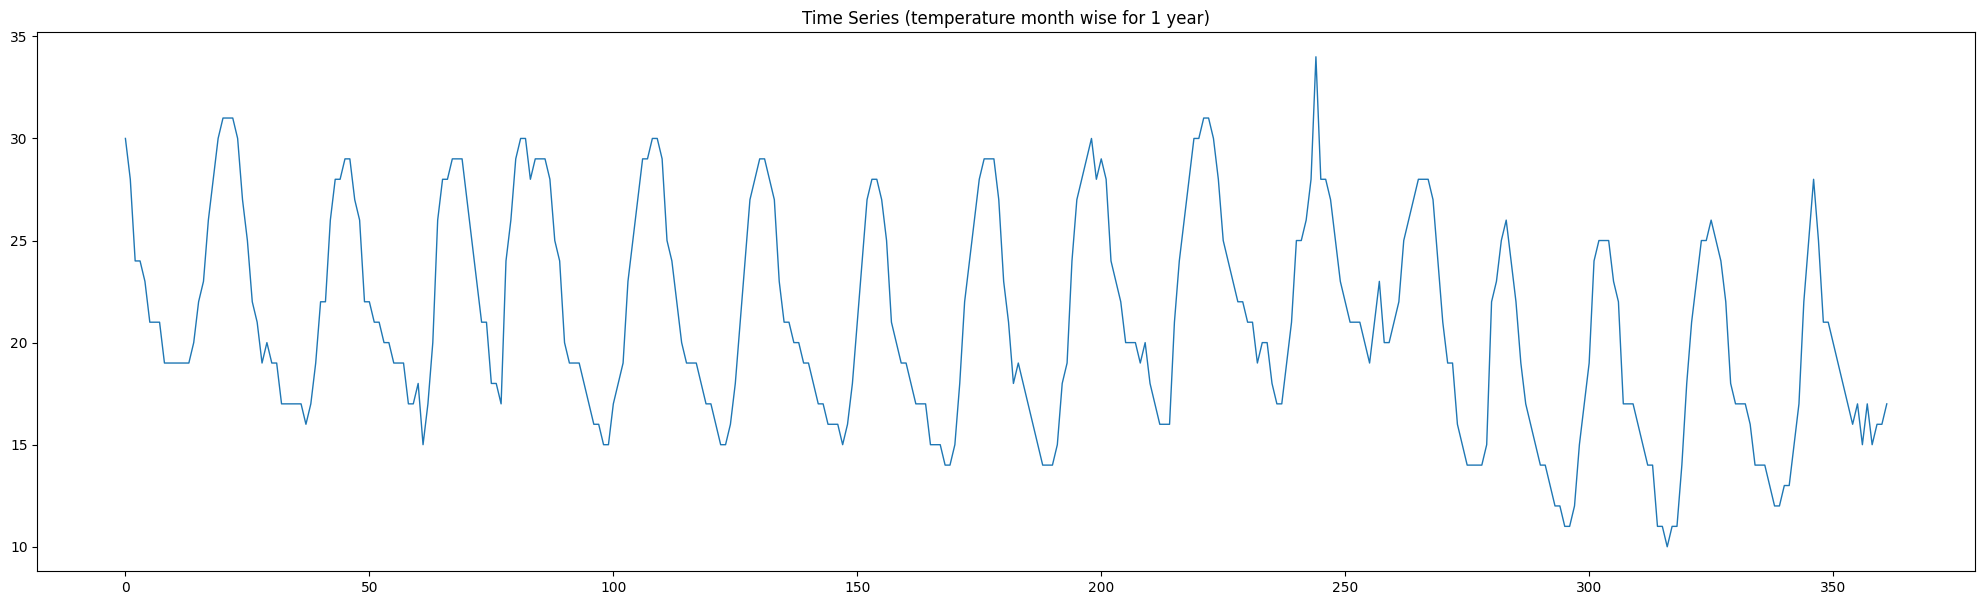

In [39]:
df=df['temp'].values
df[:5]
df=df.reshape(-1,1)
plt.figure(figsize=(25, 7))
plt.plot(df, linewidth=1)
# plt.grid()
plt.title("Time Series (temperature month wise for 1 year)")
plt.show()

In [40]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df)
data_scaled.shape

(362, 1)

In [41]:
data_scaled.shape

steps= 20
inp = []
out = []
for i in range(len(data_scaled) - (steps)):
    inp.append(data_scaled[i:i+steps])
    out.append(data_scaled[i+steps])

out[:10]

[array([0.875]),
 array([0.875]),
 array([0.875]),
 array([0.83333333]),
 array([0.70833333]),
 array([0.625]),
 array([0.5]),
 array([0.45833333]),
 array([0.375]),
 array([0.41666667])]

In [42]:
#reshape

import numpy as np
inp= np.asanyarray(inp)
out= np.asanyarray(out)

In [43]:
len(df)*0.65

235.3

In [65]:
x_train = inp[:237,:,:]
x_test = inp[237:,:,:]
y_train = out[:237]
y_test= out[237:]

inp.shape
print(x_train.shape)
print(x_test.shape)

(237, 20, 1)
(105, 20, 1)


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import Dense,RepeatVector, LSTM, Dropout
from tensorflow.keras.layers import Flatten, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model

In [46]:
model = Sequential()
model.add(LSTM(50, return_sequences= True, input_shape= (20,1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss = 'mean_squared_error', optimizer = 'adam')
model = Sequential()
model.add(LSTM(50, return_sequences= True, input_shape= (20,1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss = 'mean_squared_error', optimizer = 'adam')

In [47]:
model.fit(x_train,y_train,epochs=300, verbose=1, )

Epoch 1/300
8/8 [==============================] - 7s 29ms/step - loss: 0.1584
Epoch 2/300
8/8 [==============================] - 0s 27ms/step - loss: 0.0672
Epoch 3/300
8/8 [==============================] - 0s 31ms/step - loss: 0.0608
Epoch 4/300
8/8 [==============================] - 0s 29ms/step - loss: 0.0549
Epoch 5/300
8/8 [==============================] - 0s 30ms/step - loss: 0.0502
Epoch 6/300
8/8 [==============================] - 0s 26ms/step - loss: 0.0492
Epoch 7/300
8/8 [==============================] - 0s 28ms/step - loss: 0.0470
Epoch 8/300
8/8 [==============================] - 0s 29ms/step - loss: 0.0461
Epoch 9/300
8/8 [==============================] - 0s 29ms/step - loss: 0.0438
Epoch 10/300
8/8 [==============================] - 0s 27ms/step - loss: 0.0411
Epoch 11/300
8/8 [==============================] - 0s 27ms/step - loss: 0.0363
Epoch 12/300
8/8 [==============================] - 0s 33ms/step - loss: 0.0308
Epoch 13/300
8/8 [==============================]

In [48]:
# prediction

print("Predicted Value",model.predict(x_train)[4][0])
print("Expected value",y_train[4][0])

8/8 [==============================] - 1s 10ms/step
Predicted Value 0.7208015
Expected value 0.7083333333333334


In [49]:
predictions=model.predict(x_test)
print("Predicted Value",predictions[2][0])
print("Expected Value",y_test[2][0])

4/4 [==============================] - 0s 12ms/step
Predicted Value 0.41268307
Expected Value 0.41666666666666663


In [50]:
print(predictions.shape)
print(y_test.shape)


(105, 1)
(105, 1)


In [51]:
pred_df=pd.DataFrame(predictions)
pred_df['TrueValues']=y_test
pred_df_new = pred_df.rename(columns={ 0: 'Predictions'})
pred_df_new

,Predictions,TrueValues
0,0.443648,0.541667
1,0.558763,0.416667
2,0.412683,0.416667
3,0.425615,0.458333
4,0.502948,0.500000
...,...,...
100,0.224790,0.291667
101,0.287065,0.208333
102,0.231719,0.250000
103,0.275815,0.250000


Text(0.5, 1.0, 'Predictions VS True Values on Testing Set')

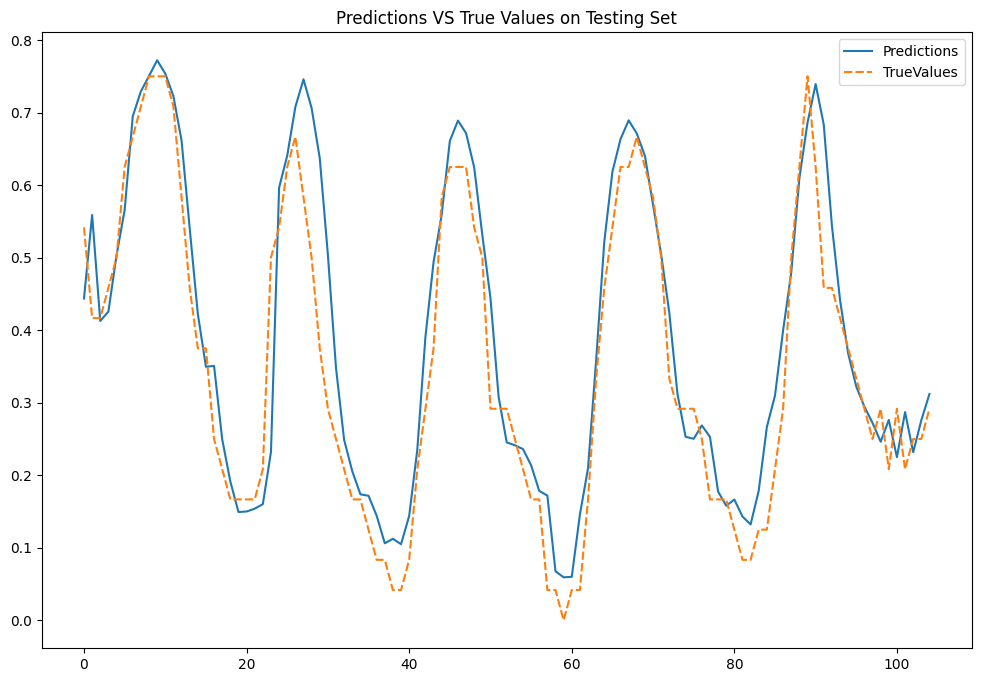

In [52]:
plt.figure(figsize=(12,8))
sns.lineplot(data= pred_df_new)
plt.title("Predictions VS True Values on Testing Set")

In [53]:
#Weather Predictions for next 30 Days
data_scaled.shape

(362, 1)

In [54]:
x_input=data_scaled[:20]
x_input.shape

(20, 1)

In [55]:
# now reshaping the data
x_input = x_input.reshape(1, -1)
x_input.shape

(1, 20)

In [56]:
temp_input = list(x_input)
temp_input = temp_input[0].tolist()

In [57]:
# demonstrate prediction for next 10 days
from numpy import array

lst_output=[]
n_steps=20
i=0
while(i<30):

    if(len(temp_input)>20):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
#         print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1


print(lst_output)

[0.8481746]
1 day input [0.75       0.58333333 0.58333333 0.54166667 0.45833333 0.45833333
 0.45833333 0.375      0.375      0.375      0.375      0.375
 0.375      0.41666667 0.5        0.54166667 0.66666667 0.75
 0.83333333 0.84817457]
1 day output [[0.84805036]]
2 day input [0.58333333 0.58333333 0.54166667 0.45833333 0.45833333 0.45833333
 0.375      0.375      0.375      0.375      0.375      0.375
 0.41666667 0.5        0.54166667 0.66666667 0.75       0.83333333
 0.84817457 0.84805036]
2 day output [[0.8157632]]
3 day input [0.58333333 0.54166667 0.45833333 0.45833333 0.45833333 0.375
 0.375      0.375      0.375      0.375      0.375      0.41666667
 0.5        0.54166667 0.66666667 0.75       0.83333333 0.84817457
 0.84805036 0.81576318]
3 day output [[0.7508658]]
4 day input [0.54166667 0.45833333 0.45833333 0.45833333 0.375      0.375
 0.375      0.375      0.375      0.375      0.41666667 0.5
 0.54166667 0.66666667 0.75       0.83333333 0.84817457 0.84805036
 0.81576318 0.7

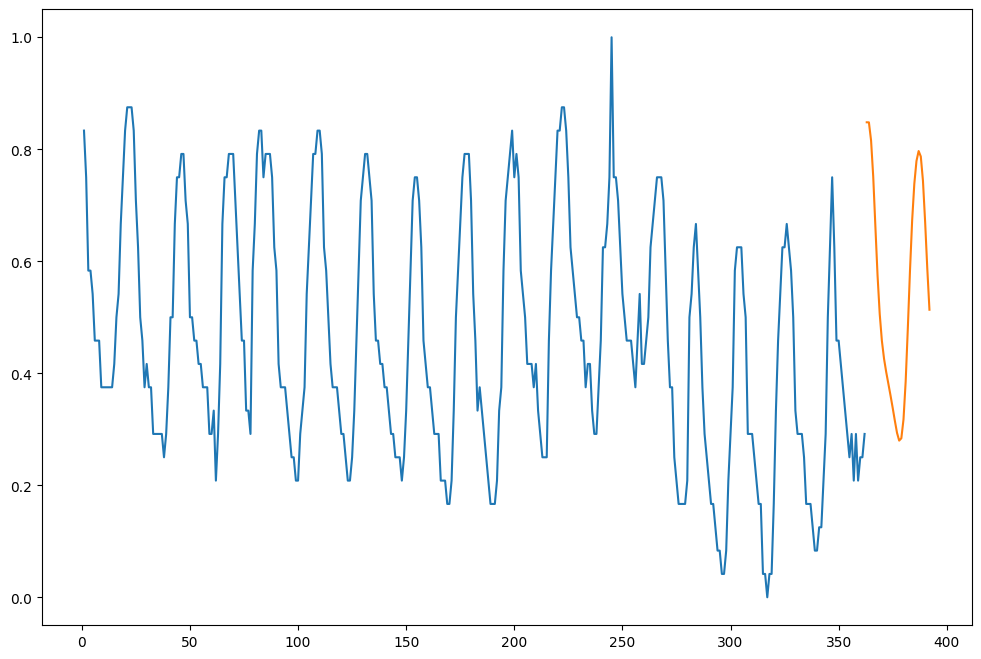

In [58]:
day_new = np.arange(1,363)
day_pred = np.arange(363,393)
plt.figure(figsize=(12,8))
plt.plot(day_new,data_scaled)
plt.plot(day_pred,lst_output)

In [59]:
data_scaled[:5]

array([[0.83333333],
       [0.75      ],
       [0.58333333],
       [0.58333333],
       [0.54166667]])

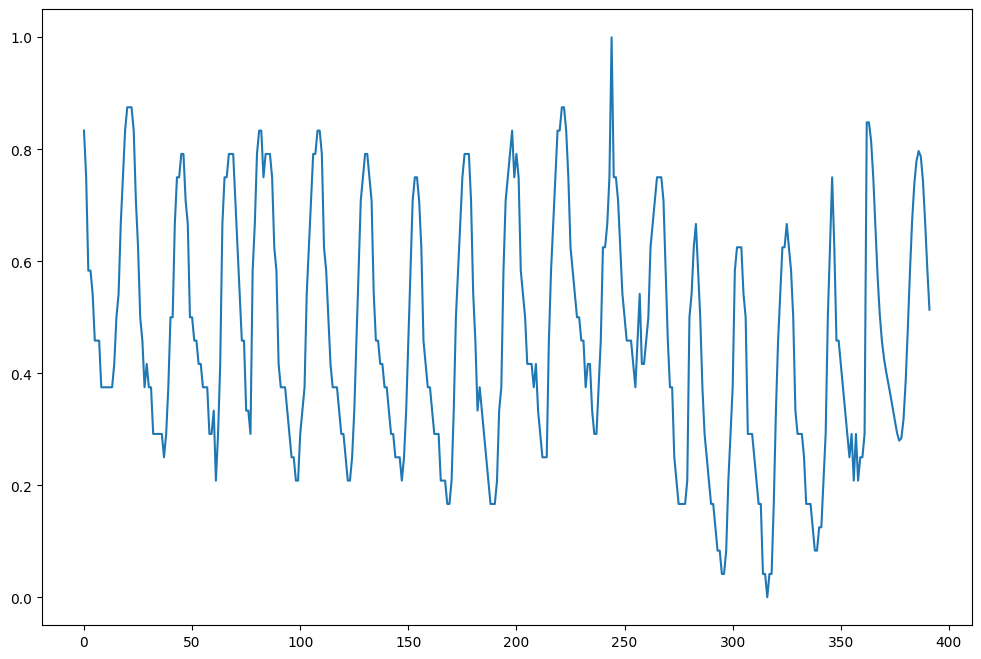

In [60]:
df3 = data_scaled.tolist()
df3.extend(lst_output)
plt.figure(figsize=(12,8))
plt.plot(df3)

In [84]:
df= pd.read_csv('testset.csv')
df.head()
data = pd.DataFrame(list(df[' _tempm']), index=df['datetime_utc'], columns=['temp'])
data.head()


,temp
datetime_utc,
19961101-11:00,30.0
19961101-12:00,28.0
19961101-13:00,24.0
19961101-14:00,24.0
19961101-16:00,23.0


In [85]:
df=data[:365]
df.shape
df.isnull().sum()
df=df.dropna(axis=0)
df.shape

(362, 1)

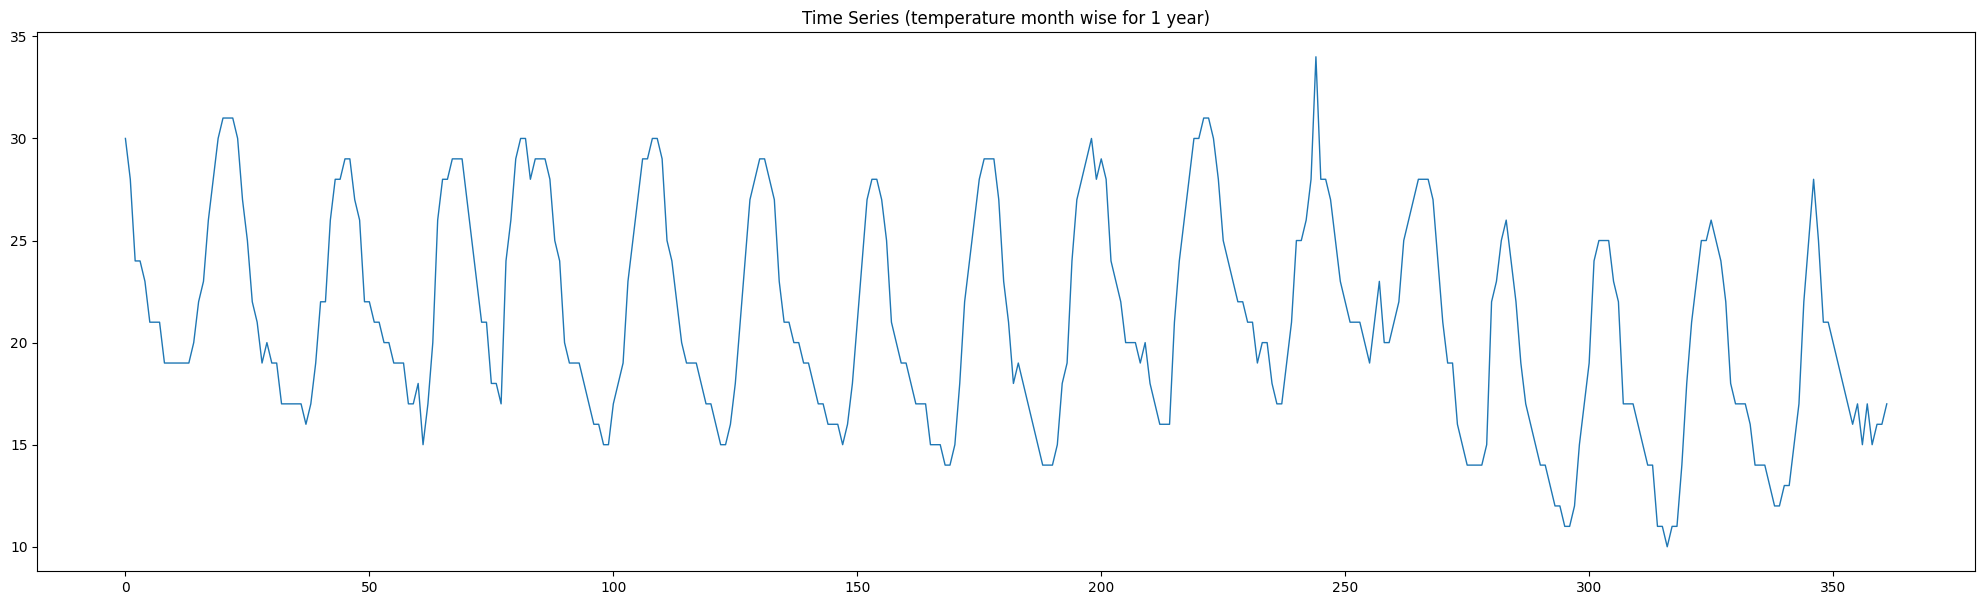

In [86]:
df=df['temp'].values
df[:5]
df=df.reshape(-1,1)
plt.figure(figsize=(25, 7))
plt.plot(df, linewidth=1)
# plt.grid()
plt.title("Time Series (temperature month wise for 1 year)")
plt.show()

In [91]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df)
data_scaled.shape


(362, 1)

In [102]:
steps= 20
inp = []
out = []
for i in range(len(data_scaled) - (steps)):
    inp.append(data_scaled[i:i+steps])
    out.append(data_scaled[i+steps])

out[:10]

[array([0.875]),
 array([0.875]),
 array([0.875]),
 array([0.83333333]),
 array([0.70833333]),
 array([0.625]),
 array([0.5]),
 array([0.45833333]),
 array([0.375]),
 array([0.41666667])]

In [103]:
#reshape

import numpy as np
inp= np.asanyarray(inp)
out= np.asanyarray(out)

In [104]:
len(df)*0.65

x_train = inp[:237,:,:]
x_test = inp[237:,:,:]
y_train = out[:237]
y_test= out[237:]

In [105]:
inp.shape
print(x_train.shape)
print(x_test.shape)

(237, 20, 1)
(105, 20, 1)


In [96]:
# Prepare data for GRU
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [100]:
# Assuming 'df' should be a Pandas DataFrame and you have the original data available
import pandas as pd

# Recreate the DataFrame (replace 'your_data' with the original data source)
df = pd.DataFrame(data_scaled)

seq_length = 10
# Ensure numerical_cols contains valid column names present in df
X, y = create_sequences(df[df.columns.intersection(numerical_cols)].values, seq_length)

In [108]:
from tensorflow.keras.layers import GRU, Dense

# Build GRU model
model = Sequential()
model.add(GRU(50, activation='relu', input_shape=(20,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train,y_train, epochs=50, batch_size=32)  # Adjust epochs and batch size


Epoch 1/50
8/8 [==============================] - 2s 10ms/step - loss: 0.2426
Epoch 2/50
8/8 [==============================] - 0s 12ms/step - loss: 0.1521
Epoch 3/50
8/8 [==============================] - 0s 9ms/step - loss: 0.0815
Epoch 4/50
8/8 [==============================] - 0s 10ms/step - loss: 0.0382
Epoch 5/50
8/8 [==============================] - 0s 12ms/step - loss: 0.0252
Epoch 6/50
8/8 [==============================] - 0s 12ms/step - loss: 0.0257
Epoch 7/50
8/8 [==============================] - 0s 10ms/step - loss: 0.0217
Epoch 8/50
8/8 [==============================] - 0s 11ms/step - loss: 0.0208
Epoch 9/50
8/8 [==============================] - 0s 10ms/step - loss: 0.0201
Epoch 10/50
8/8 [==============================] - 0s 10ms/step - loss: 0.0192
Epoch 11/50
8/8 [==============================] - 0s 11ms/step - loss: 0.0186
Epoch 12/50
8/8 [==============================] - 0s 10ms/step - loss: 0.0181
Epoch 13/50
8/8 [==============================] - 0s 12ms/ste

In [109]:
# prediction

print("Predicted Value",model.predict(x_train)[4][0])
print("Expected value",y_train[4][0])

8/8 [==============================] - 0s 4ms/step
Predicted Value 0.72551894
Expected value 0.7083333333333334


In [110]:
predictions=model.predict(x_test)
print("Predicted Value",predictions[2][0])
print("Expected Value",y_test[2][0])

4/4 [==============================] - 0s 4ms/step
Predicted Value 0.4822201
Expected Value 0.41666666666666663


In [111]:
print(predictions.shape)
print(y_test.shape)

(105, 1)
(105, 1)


In [112]:
pred_df=pd.DataFrame(predictions)
pred_df['TrueValues']=y_test
pred_df_new = pred_df.rename(columns={ 0: 'Predictions'})
pred_df_new

,Predictions,TrueValues
0,0.431437,0.541667
1,0.513501,0.416667
2,0.482220,0.416667
3,0.447170,0.458333
4,0.455202,0.500000
...,...,...
100,0.293961,0.291667
101,0.328636,0.208333
102,0.309978,0.250000
103,0.319992,0.250000


Text(0.5, 1.0, 'Predictions VS True Values on Testing Set')

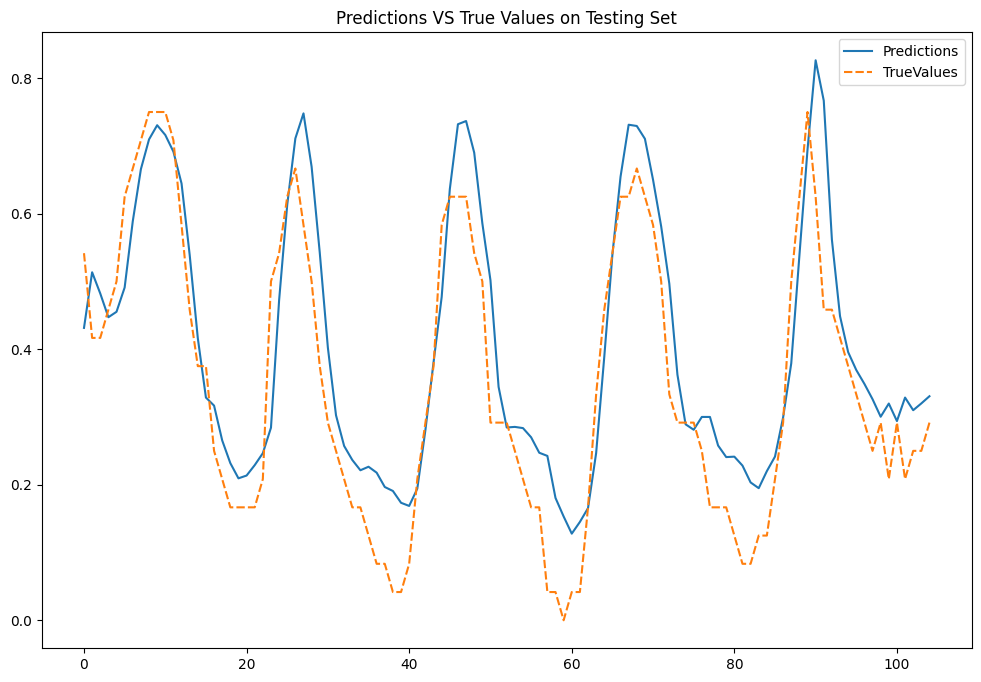

In [113]:
plt.figure(figsize=(12,8))
sns.lineplot(data= pred_df_new)
plt.title("Predictions VS True Values on Testing Set")